### General Plan 
### Load the csv and pick the most popular 2023 dramas 
### Turn csv titles into Wikipedia page names and check with mwclient
### Get the daily pageviews from 2022-2024 with mwviews and put them in a dataframe 
### Make the plots with Matplotlib

## Graph 1 (Bar Chart)

In [2]:
%pip install pandas numpy 
%pip install matplotlib
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from mwclient import Site
from mwviews.api import PageviewsClient

dramas = pd.read_csv("kdramas_2023.csv")
dramas.columns.tolist()


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 30.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 25.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 17.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


['Unnamed: 0',
 'Year',
 'Title_English',
 'Episodes',
 'Popularity',
 'Aired',
 'Aired On',
 'Duration',
 'Genres',
 'Tags',
 'Summary',
 'Title_Korean',
 'Also Known As',
 'Content Rating',
 'Score_Votes',
 'Score',
 'Ranked',
 'Watchers']

In [3]:
# lower Popularity number = more popular, so sort and take the top 20
top = dramas.sort_values("Popularity").head(20)
top[["Title_English", "Popularity", "Aired"]]

,Title_English,Popularity,Aired
21,Twinkling Watermelon (2023),18,"Sep 25, 2023 - Nov 14, 2023"
4,My Demon (2023),40,"Nov 24, 2023 - Jan 20, 2024"
34,King the Land (2023),42,"Jun 17, 2023 - Aug 6, 2023"
50,The Glory Part 2 (2023),72,"Mar 10, 2023"
62,Moving (2023),85,"Aug 9, 2023 - Sep 20, 2023"
129,Death's Game (2023),107,"Dec 15, 2023"
193,Welcome to Samdal-ri (2023),117,"Dec 2, 2023 - Jan 21, 2024"
144,Bloodhounds (2023),124,"Jun 9, 2023"
92,See You in My 19th Life (2023),125,"Jun 17, 2023 - Jul 23, 2023"
65,Destined with You (2023),146,"Aug 23, 2023 - Oct 12, 2023"


In [ ]:
#brainstorming 
site = Site('en.wikipedia.org')

for t in top["Title_English"]:
    page = site.pages[t]
    print(t, page.exists)

# everything is False, because every title ends with " (2023)"

Twinkling Watermelon (2023) False
My Demon (2023) False
King the Land (2023) False
The Glory Part 2 (2023) False
Moving (2023) False
Death's Game (2023) False
Welcome to Samdal-ri (2023) False
Bloodhounds (2023) False
See You in My 19th Life (2023) False
Destined with You (2023) False
The Good Bad Mother (2023) False
My Lovely Liar (2023) False
Crash Course in Romance (2023) False
Love to Hate You (2023) False
Perfect Marriage Revenge (2023) False
A Time Called You (2023) False
Doona! (2023) False
Celebrity (2023) False
Daily Dose of Sunshine (2023) False
Gyeongseong Creature (2023) False


In [5]:
# checking again with removing 2023 from titles 
top["wiki_title"] = top["Title_English"].str.replace(" (2023)", "", regex=False)

for t in top["wiki_title"]:
    page = site.pages[t]
    print(t, page.exists)

Twinkling Watermelon True
My Demon True
King the Land True
The Glory Part 2 False
Moving True
Death's Game True
Welcome to Samdal-ri True
Bloodhounds True
See You in My 19th Life True
Destined with You True
The Good Bad Mother True
My Lovely Liar True
Crash Course in Romance True
Love to Hate You True
Perfect Marriage Revenge True
A Time Called You True
Doona! True
Celebrity True
Daily Dose of Sunshine True
Gyeongseong Creature True


In [ ]:
# exploring some pages common word titles 
for t in ["The Glory Part 2", "Moving", "Celebrity", "Love to Hate You"]:
    page = site.pages[t]
    print(t, "->", page.exists)
    print(page.text()[:150])
    print("-----")

# "The Glory Part 2" has no page, and the other three are not about the dramas so I had to manually change these names 

The Glory Part 2 -> False

-----
Moving -> True
{{Wiktionary|moving}}
{{Self reference|For the Wikipedia how-to guide, see [[Wikipedia:Moving a page]]}}
'''Moving''' or '''Movin'''' may refer to:
{{
-----
Celebrity -> True
{{Short description|Fame in mass media}}
{{Other uses}}
{{Redirect|Television personalities|the band|Television Personalities}}
{{Redirect|Star (perso
-----
Love to Hate You -> True
{{Short description|1991 single by Erasure}}
{{For|the South Korean streaming television series|Love to Hate You (TV series)}}
{{Use dmy dates|date=Se
-----


In [ ]:
# manually changing wrong names with a dictionary
fixes = {"The Glory Part 2": "The Glory (TV series)",
         "Moving": "Moving (South Korean TV series)",
         "Celebrity": "Celebrity (South Korean TV series)",
         "Love to Hate You": "Love to Hate You (TV series)"}

top["wiki_title"] = top["wiki_title"].replace(fixes)

# the graphs I'm copying don't include Bloodhounds, so I dropped it to match them
top = top[top["wiki_title"] != "Bloodhounds"]

for t in top["wiki_title"]:
    print(t, site.pages[t].exists)

# all True, 19 shows 

Twinkling Watermelon True
My Demon True
King the Land True
The Glory (TV series) True
Moving (South Korean TV series) True
Death's Game True
Welcome to Samdal-ri True
See You in My 19th Life True
Destined with You True
The Good Bad Mother True
My Lovely Liar True
Crash Course in Romance True
Love to Hate You (TV series) True
Perfect Marriage Revenge True
A Time Called You True
Doona! True
Celebrity (South Korean TV series) True
Daily Dose of Sunshine True
Gyeongseong Creature True


In [65]:
#getting titles 
titles = top["wiki_title"].tolist()
len(titles)

# getting page veiws from same date range as the bar chart title
p = PageviewsClient(user_agent="CS315 Student learning about Wikipedia")
data = p.article_views('en.wikipedia', titles, start='20220601', end='20240601')

type(data)

collections.defaultdict

In [74]:
#turning dictionary into a df 
views = pd.DataFrame(data)
views.iloc[:3, :3]

#  the dates are the columns and the shows are the rows 

,2022-06-01,2022-06-02,2022-06-03
Twinkling_Watermelon,NaN,NaN,NaN
My_Demon,NaN,NaN,NaN
King_the_Land,NaN,NaN,NaN


In [81]:
# fliping it so each row is a day and each column is a show
views = pd.DataFrame(data).T
views.index = pd.to_datetime(views.index)
views = views.astype(float)
views.head()

,Twinkling_Watermelon,My_Demon,King_the_Land,The_Glory_(TV_series),Moving_(South_Korean_TV_series),Death's_Game,Welcome_to_Samdal-ri,See_You_in_My_19th_Life,Destined_with_You,The_Good_Bad_Mother,My_Lovely_Liar,Crash_Course_in_Romance,Love_to_Hate_You_(TV_series),Perfect_Marriage_Revenge,A_Time_Called_You,Doona!,Celebrity_(South_Korean_TV_series),Daily_Dose_of_Sunshine,Gyeongseong_Creature
2022-06-01,NaN,NaN,NaN,NaN,199.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134.0,NaN,NaN,NaN,NaN
2022-06-02,NaN,NaN,NaN,NaN,176.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128.0,NaN,NaN,NaN,NaN
2022-06-03,NaN,NaN,NaN,NaN,183.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.0,NaN,NaN,NaN,NaN
2022-06-04,NaN,NaN,NaN,NaN,167.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154.0,NaN,NaN,NaN,NaN
2022-06-05,NaN,NaN,NaN,NaN,212.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,137.0,NaN,NaN,NaN,NaN


In [97]:
# obtaining show by name 
print("The Glory (TV series)" in views.columns)
print(views.columns.tolist()[:3])

#  mwviews gives back the names with underscores (The_Glory_(TV_series))
# this caused error so I manually replaced the underscores with spaces


views.columns = views.columns.str.replace("_", " ")
print("The Glory (TV series)" in views.columns)

True
['Twinkling Watermelon', 'My Demon', 'King the Land']
True


<BarContainer object of 19 artists>

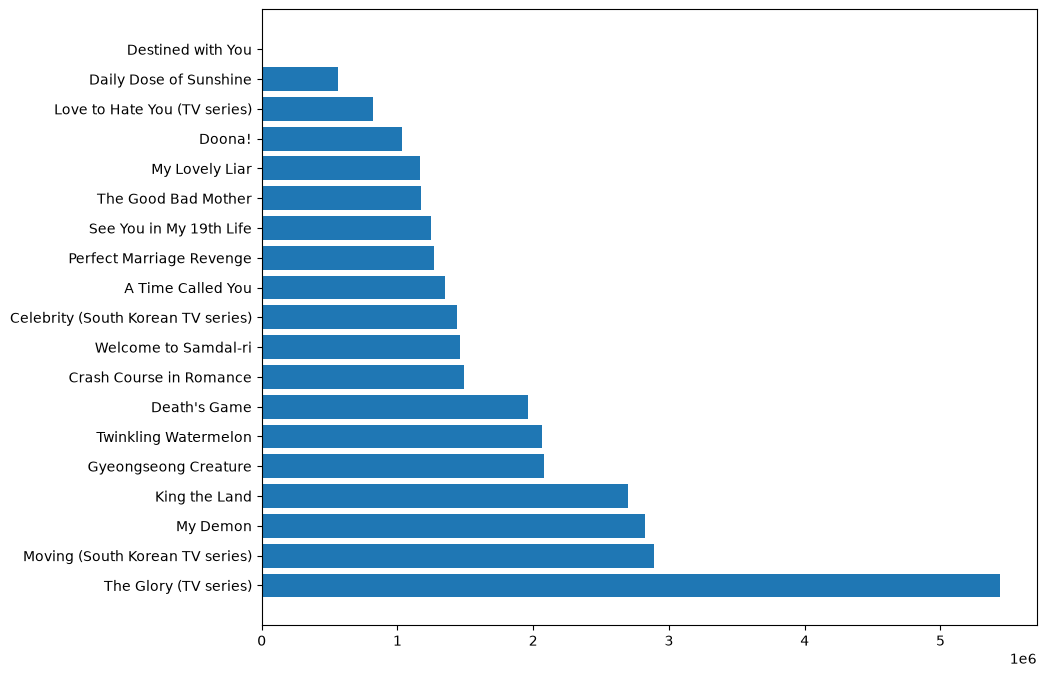

In [103]:
# plotting a bar chart 
totals = views.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(totals.index, totals.values)

# the biggest show is at the bottom, but in the original it's at the top

## Bar Chart Final

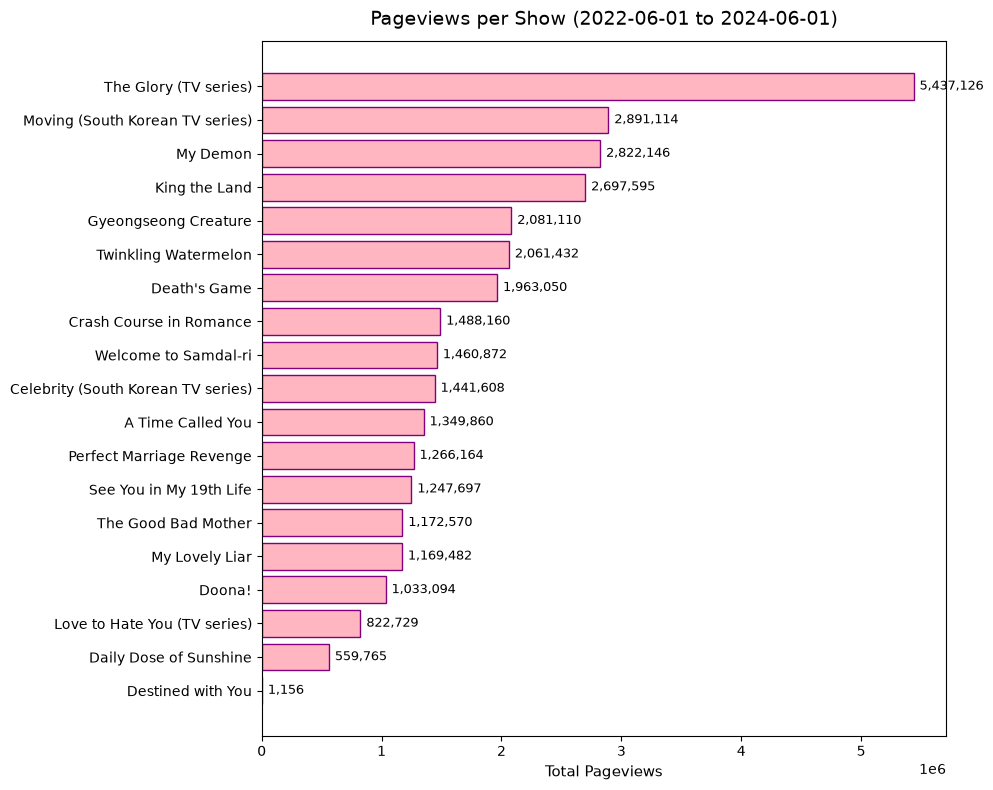

In [108]:
#BAR CHART FINAL 
#  sort the other way so the biggest bar is on top, and add the numbers
totals = views.sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(totals.index, totals.values, color="lightpink", edgecolor="purple")

for i in range(len(totals)):
    value = int(totals.values[i])
    ax.text(value + 50000, i, f"{value:,}", va="center", fontsize=9)

ax.set_title("Pageviews per Show (2022-06-01 to 2024-06-01)", fontsize=14, pad=12)
ax.set_xlabel("Total Pageviews", fontsize=11)
fig.tight_layout()
plt.savefig("barchart-pageviews-new.png")
plt.show()

## Graph 2 Area Chart

In [112]:
# finding the peak date of one show and counting the days 
show = views["The Glory (TV series)"].dropna()
peak = show.idxmax()
days = (show.index - peak).days

print(peak.date())
print(days[:5])

2023-03-12
Index([-231, -230, -229, -228, -227], dtype='int64')


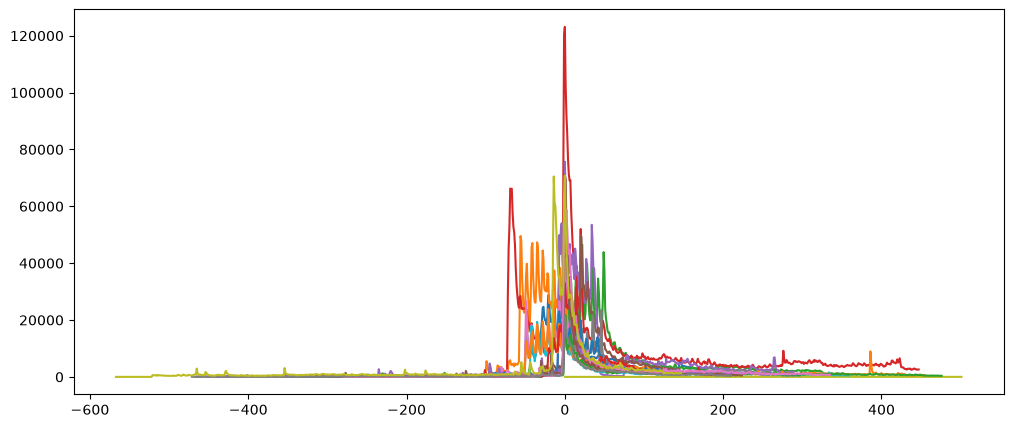

In [115]:
#  put all the shows on one plot
fig, ax = plt.subplots(figsize=(12, 5))

for name in titles:
    show = views[name].dropna()
    days = (show.index - show.idxmax()).days
    ax.plot(days, show.values)

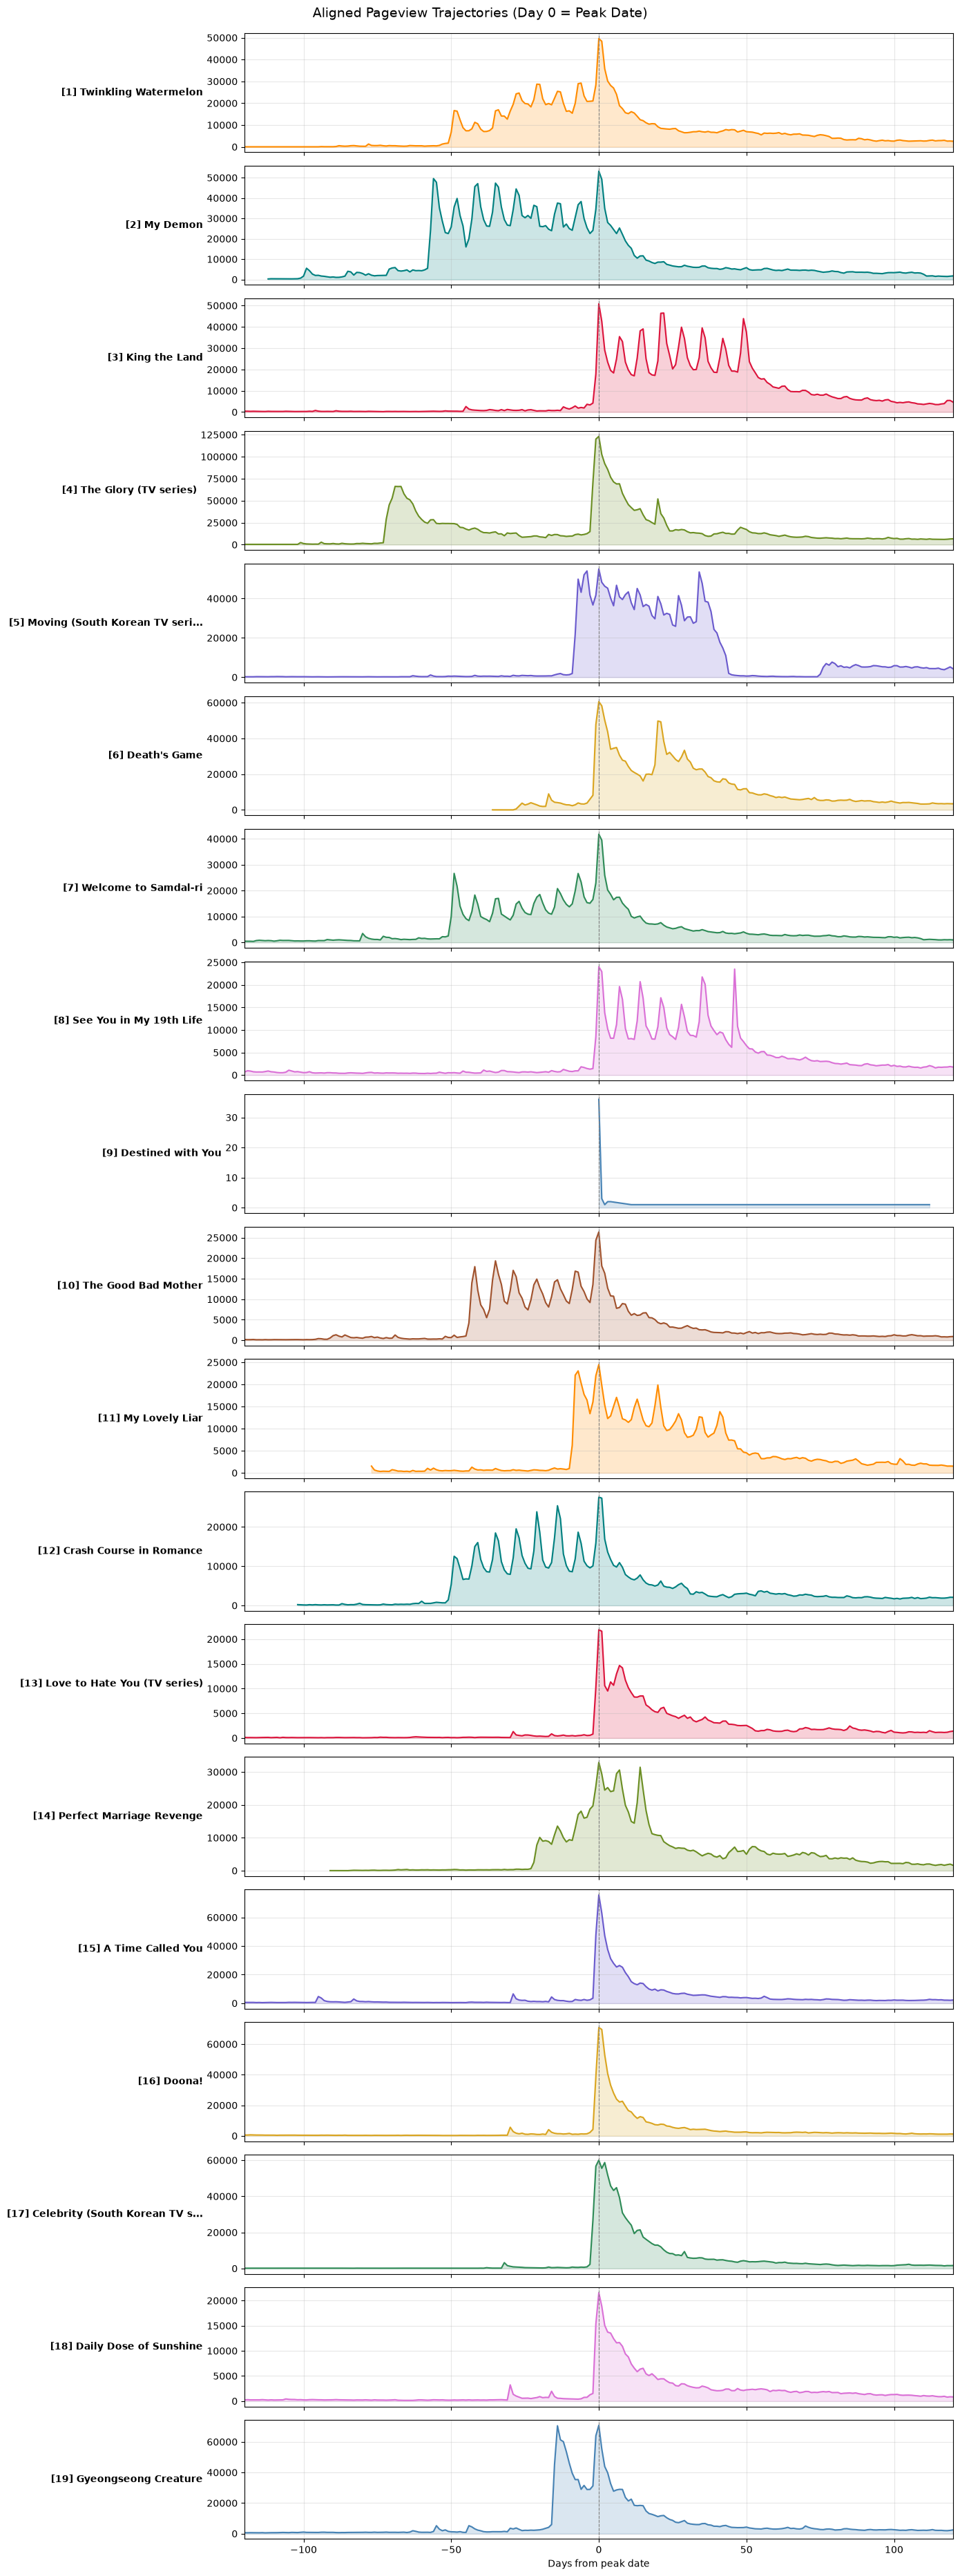

In [116]:

colors = ["darkorange", "teal", "crimson", "olivedrab", "slateblue",
          "goldenrod", "seagreen", "orchid", "steelblue", "sienna"]

fig, axes = plt.subplots(nrows=len(titles), ncols=1, figsize=(14, 2 * len(titles)), sharex=True)

for i in range(len(titles)):
    name = titles[i]
    ax = axes[i]
    color = colors[i % len(colors)]

    show = views[name].dropna()
    days = (show.index - show.idxmax()).days
    keep = (days >= -120) & (days <= 120)
    days = days[keep]
    values = show.values[keep]

    ax.plot(days, values, color=color)
    ax.fill_between(days, values, color=color, alpha=0.2)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.grid(alpha=0.3)
    ax.set_xlim(-120, 120)

    label = name
    if len(label) > 28:
        label = label[:28] + "..."
    ax.set_ylabel(f"[{i + 1}] {label}", rotation=0, ha="right", va="center", fontweight="bold")

axes[-1].set_xlabel("Days from peak date")
fig.suptitle("Aligned Pageview Trajectories (Day 0 = Peak Date)", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.97)
plt.savefig("aligned-trajectories-new.png")
plt.show()

